<a id="libraries"></a>
<h1 style="text-align:center;">
    <b><span style="color:#800000">Third Notebook</span></b>
</h1>



<a id="libraries"></a>
# <b><span style='color:#0000FF'>A Comparative Analysis: </span><span style='color:#0000FF'> Machine Learning vs. Statistical Models</span></b>

## Part 3: Time Series Forecasting 


#### 🎯 Objective
The comparison here is between one of the most foundational models in econometrics and a powerful, modern deep learning architecture:

- **ARIMA (The "Classical" Statistical Model)**: A model that is statistically rigorous and highly interpretable. We will use `the statsmodels library` to implement the Box-Jenkins methodology, which involves identifying the underlying statistical properties of a single time series (its auto-regression, trends, and moving averages) to create a forecast.

- **RNN/LSTM (The "Deep Learning" Model)**: A model designed to learn complex, non-linear patterns and long-term dependencies in sequential data. We will use `PyTorch` to build a Long Short-Term Memory (LSTM) network. Unlike ARIMA, this model can easily function as a "black box," learning patterns from multiple input series (multivariate) to predict an outcome.

#### 📦 Datasets
We will explore a variety of common forecasting problems. These datasets will be sourced from public repositories and will provide a mix of seasonal, trend-driven, and complex/volatile data to test the limits of both models:

- **Energy Consumption**: Often exhibits strong, clear seasonality and trends.

- **Stock Prices**: Famously "noisy" and difficult to model; a classic test for predictive power.

- **Temperature**: A good example of data with both a long-term trend (climate) and strong seasonality (annual).

- **Sales Forecasting**: A common business problem where forecasts must account for seasonality, holidays, and other external factors (exogenous variables).

<a id="contents_tabel"></a>    
<div style="border-radius:10px; padding: 15px; background-color: #FFFFFF; font-size:130%; text-align:left">

<h2 align="left"><font color=#6a7f7a>Table of Contents:</font></h2>
    
* [Step 1 | Importing Necessary Libraries](#libraries)
   
* [Step 2 | Exploratory Data Analysis (EDA) for all  📦 Datasets ](#eda) 
    
* [Step 3 |  Data Preprocessing & Training ](#DP) 
    - [Step 3.1 | 🔧 Data Preprocessing for Energy Consumption](#DP1) 
    - [Step 3.2 | 🔧 Data Preprocessing for 📈 STOCK PRICES DATASET](#DP2)
    - [Step 3.3 | 🔧 Data Preprocessing for 🌡️ TEMPERATURE DATASET](#DP3) 
    - [Step 3.4 | 🔧 Data Preprocessing for 💰 SALES FORECASTING DATASET](#DP4)
    
* [Step 4 |   COMPREHENSIVE GENERAL COMPARISON & CONCLUSION ](#Cg) 

    


<a id="libraries"></a>
# <b><span style='color:#09ba80'>Step 1 |</span><span style='color:#34e3ae'> Importing Necessary Libraries</span></b>
- This section imports all necessary packages, groups them by function, and loads the datasets we will use for the analysis.
⬆️ [Tabel of Contents](#contents_tabel)

In [3]:
# Import necessary libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import time

# Statistical Models (Time Series)
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

# ML/DL Models (Time Series) - PyTorch
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader
    TORCH_AVAILABLE = True
    print(f"PyTorch version: {torch.__version__}")
except ImportError:
    print("⚠️  PyTorch not available. RNN models will not be trained.")
    TORCH_AVAILABLE = False

# Set style
#plt.style.use('seaborn-v0_8-darkgrid')
#sns.set_palette("husl")

# Set random seeds for reproducibility
if TORCH_AVAILABLE:
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(42)

print("✅ All libraries imported successfully!")


PyTorch version: 2.2.2
✅ All libraries imported successfully!


<a id="eda"></a>
# <b><span style='color:#09ba80'>Step 2 | </span><span style='color:#34e3ae'>Exploratory Data Analysis (EDA) for  📦 Datasets  </span></b>
⬆️ [Tabel of Contents](#contents_tabel)

📊 EDA for Energy Consumption Time Series

1. Dataset Overview:
   - Length: 1000 time steps
   - Frequency: Daily
   - Date range: 2020-01-01 to 2022-09-26

2. Basic Statistics:
   - Mean: 126.40
   - Median: 126.25
   - Std: 20.66
   - Min: 74.94
   - Max: 177.77

3. Time Series Properties:
   - Trend: Upward (increasing over time)
   - Seasonality: Present (annual and weekly cycles)
   - Noise: Random variation

4. Stationarity Test (ADF):
   - ADF Statistic: -2.0951
   - p-value: 0.2465
   - Stationary: No (p-value > 0.05 indicates non-stationary)


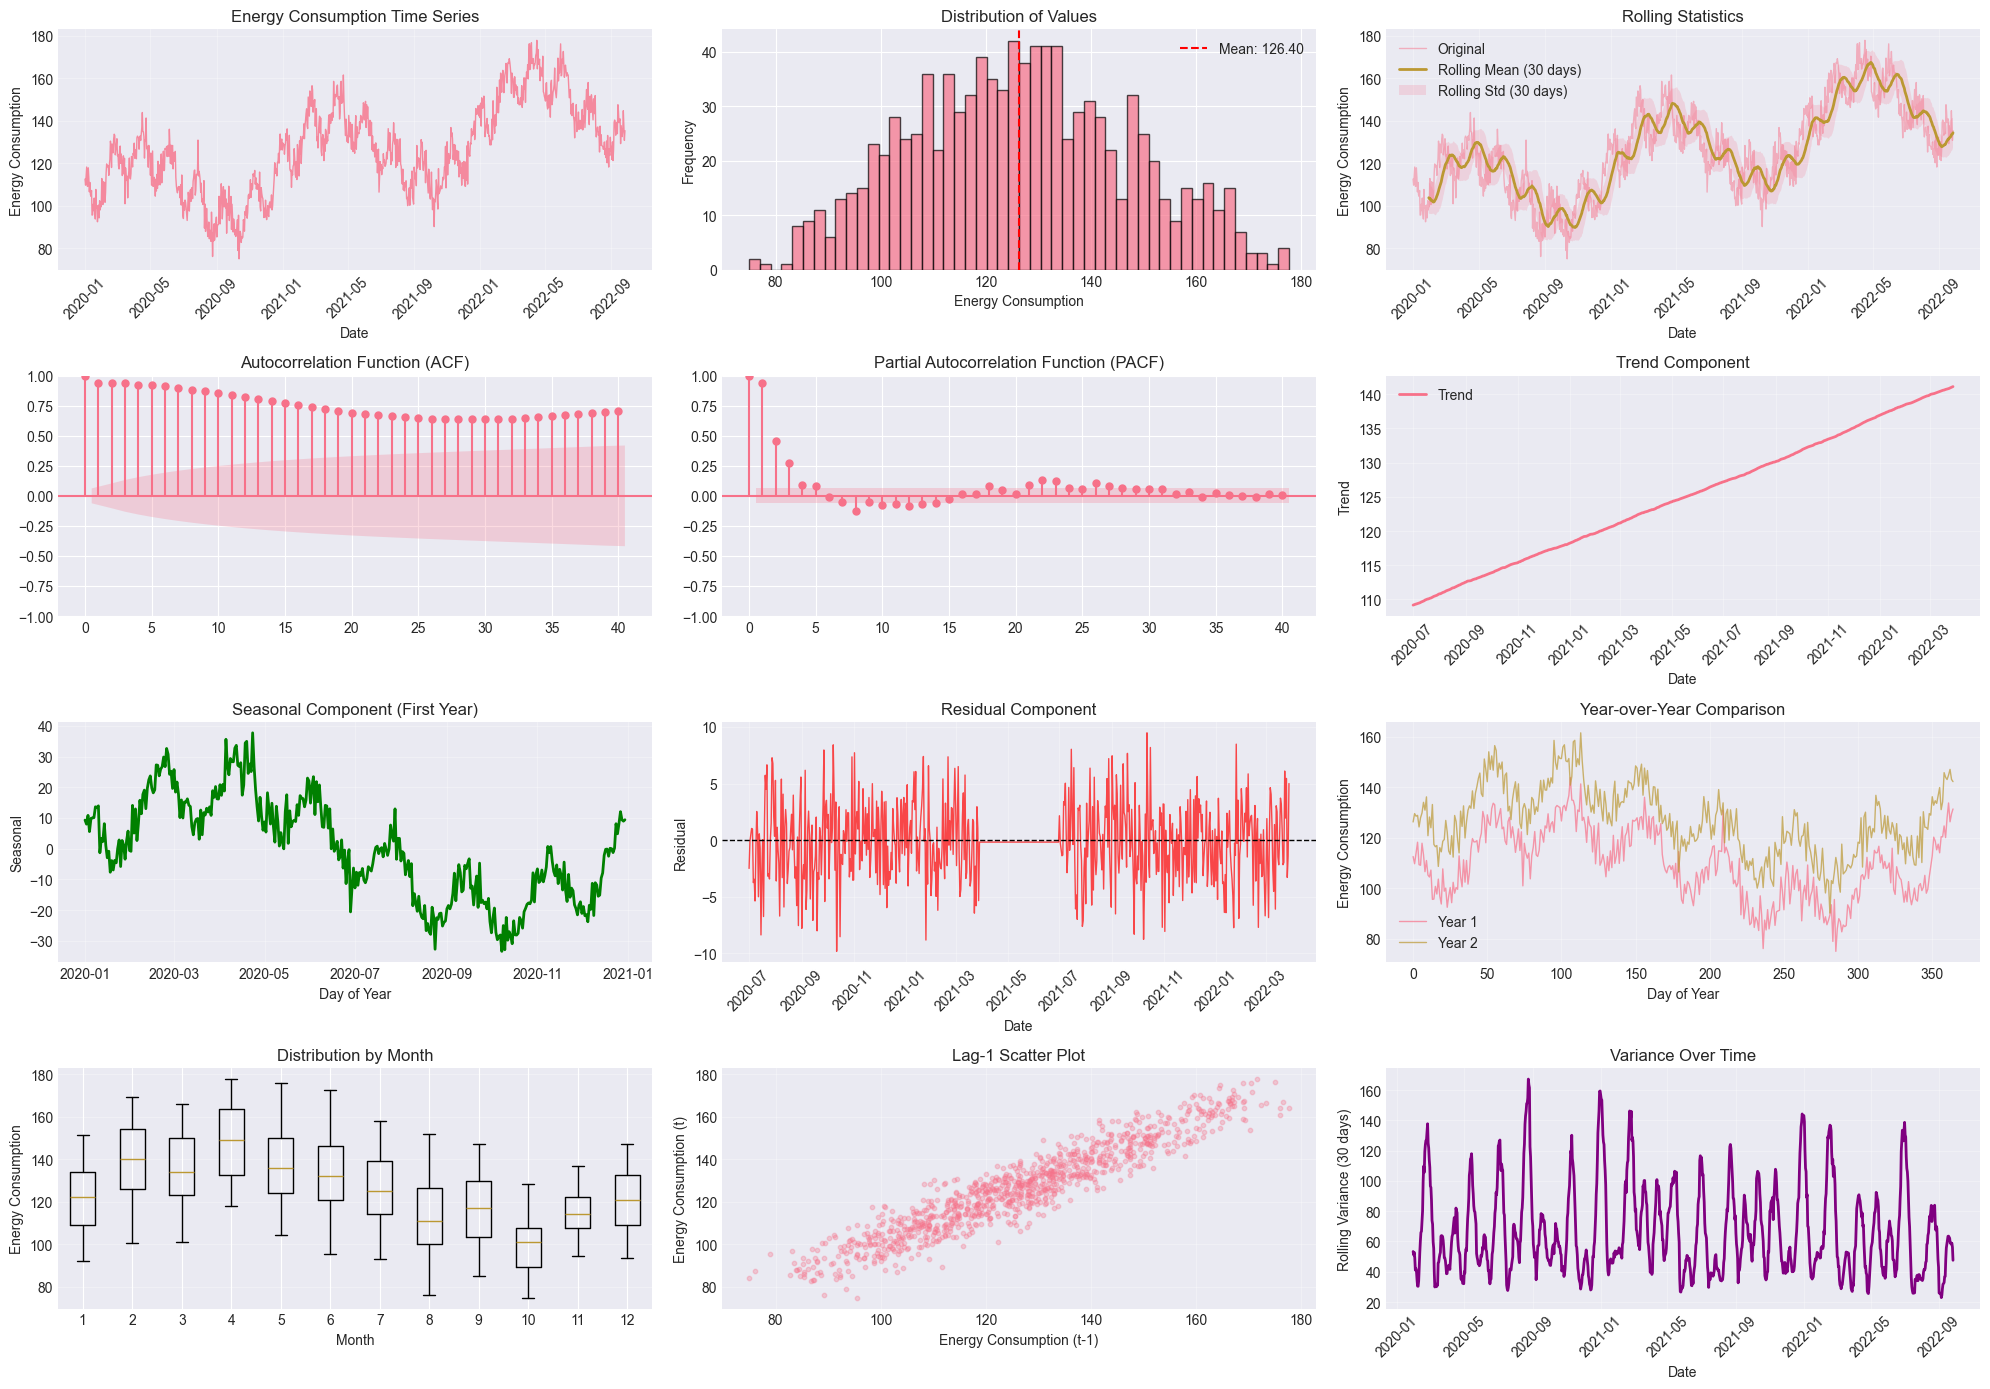


✅ Energy Consumption EDA complete!


In [33]:
print("📊 EDA for Energy Consumption Time Series")
print("=" * 80)

# Generate synthetic energy consumption time series
np.random.seed(42)
n_samples = 1000
t = np.arange(n_samples)

# Create trend + seasonality + noise
trend = 100 + 0.05 * t
seasonal = 20 * np.sin(2 * np.pi * t / 365) + 10 * np.cos(2 * np.pi * t / 52)
noise = np.random.randn(n_samples) * 5
data = trend + seasonal + noise

# Create time index
dates = pd.date_range(start='2020-01-01', periods=n_samples, freq='D')
ts = pd.Series(data, index=dates)

print(f"\n1. Dataset Overview:")
print(f"   - Length: {len(ts)} time steps")
print(f"   - Frequency: Daily")
print(f"   - Date range: {ts.index[0].date()} to {ts.index[-1].date()}")

print(f"\n2. Basic Statistics:")
print(f"   - Mean: {ts.mean():.2f}")
print(f"   - Median: {ts.median():.2f}")
print(f"   - Std: {ts.std():.2f}")
print(f"   - Min: {ts.min():.2f}")
print(f"   - Max: {ts.max():.2f}")

print(f"\n3. Time Series Properties:")
print(f"   - Trend: Upward (increasing over time)")
print(f"   - Seasonality: Present (annual and weekly cycles)")
print(f"   - Noise: Random variation")

# Stationarity test
adf_result = adfuller(ts)
print(f"\n4. Stationarity Test (ADF):")
print(f"   - ADF Statistic: {adf_result[0]:.4f}")
print(f"   - p-value: {adf_result[1]:.4f}")
print(f"   - Stationary: {'No' if adf_result[1] > 0.05 else 'Yes'} (p-value > 0.05 indicates non-stationary)")

# Visualizations
fig = plt.figure(figsize=(20, 14))

# 1. Time series plot
ax1 = plt.subplot(4, 3, 1)
ax1.plot(ts.index, ts.values, linewidth=1, alpha=0.8)
ax1.set_xlabel('Date')
ax1.set_ylabel('Energy Consumption')
ax1.set_title('Energy Consumption Time Series')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Distribution
ax2 = plt.subplot(4, 3, 2)
ax2.hist(ts.values, bins=50, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Energy Consumption')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Values')
ax2.axvline(ts.mean(), color='r', linestyle='--', label=f'Mean: {ts.mean():.2f}')
ax2.legend()

# 3. Rolling statistics
ax3 = plt.subplot(4, 3, 3)
rolling_mean = ts.rolling(window=30).mean()
rolling_std = ts.rolling(window=30).std()
ax3.plot(ts.index, ts.values, label='Original', alpha=0.5, linewidth=1)
ax3.plot(ts.index, rolling_mean, label='Rolling Mean (30 days)', linewidth=2)
ax3.fill_between(ts.index, rolling_mean - rolling_std, rolling_mean + rolling_std, 
                  alpha=0.2, label='Rolling Std (30 days)')
ax3.set_xlabel('Date')
ax3.set_ylabel('Energy Consumption')
ax3.set_title('Rolling Statistics')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

# 4. ACF plot
ax4 = plt.subplot(4, 3, 4)
plot_acf(ts, lags=40, ax=ax4, alpha=0.05)
ax4.set_title('Autocorrelation Function (ACF)')

# 5. PACF plot
ax5 = plt.subplot(4, 3, 5)
plot_pacf(ts, lags=40, ax=ax5, alpha=0.05)
ax5.set_title('Partial Autocorrelation Function (PACF)')

# 6. Seasonal decomposition (trend, seasonal, residual)
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(ts, model='additive', period=365)
ax6 = plt.subplot(4, 3, 6)
ax6.plot(decomposition.trend, label='Trend', linewidth=2)
ax6.set_xlabel('Date')
ax6.set_ylabel('Trend')
ax6.set_title('Trend Component')
ax6.legend()
ax6.grid(True, alpha=0.3)
ax6.tick_params(axis='x', rotation=45)

# 7. Seasonal component
ax7 = plt.subplot(4, 3, 7)
ax7.plot(decomposition.seasonal[:365], linewidth=2, color='green')
ax7.set_xlabel('Day of Year')
ax7.set_ylabel('Seasonal')
ax7.set_title('Seasonal Component (First Year)')
ax7.grid(True, alpha=0.3)

# 8. Residuals
ax8 = plt.subplot(4, 3, 8)
ax8.plot(decomposition.resid, linewidth=1, alpha=0.7, color='red')
ax8.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax8.set_xlabel('Date')
ax8.set_ylabel('Residual')
ax8.set_title('Residual Component')
ax8.grid(True, alpha=0.3)
ax8.tick_params(axis='x', rotation=45)

# 9. Year-over-year comparison
ax9 = plt.subplot(4, 3, 9)
if len(ts) >= 365:
    year1 = ts[:365].values
    year2 = ts[365:730].values if len(ts) >= 730 else ts[:365].values
    days = np.arange(365)
    ax9.plot(days, year1, label='Year 1', alpha=0.7, linewidth=1)
    if len(ts) >= 730:
        ax9.plot(days, year2, label='Year 2', alpha=0.7, linewidth=1)
    ax9.set_xlabel('Day of Year')
    ax9.set_ylabel('Energy Consumption')
    ax9.set_title('Year-over-Year Comparison')
    ax9.legend()
    ax9.grid(True, alpha=0.3)

# 10. Box plot by month
ax10 = plt.subplot(4, 3, 10)
ts_df = pd.DataFrame({'value': ts.values, 'month': ts.index.month})
box_data = [ts_df[ts_df['month'] == m]['value'].values for m in range(1, 13)]
ax10.boxplot(box_data, labels=range(1, 13))
ax10.set_xlabel('Month')
ax10.set_ylabel('Energy Consumption')
ax10.set_title('Distribution by Month')
ax10.grid(True, alpha=0.3, axis='y')

# 11. Lag plot
ax11 = plt.subplot(4, 3, 11)
lag1 = ts[:-1].values
lag0 = ts[1:].values
ax11.scatter(lag1, lag0, alpha=0.3, s=10)
ax11.set_xlabel('Energy Consumption (t-1)')
ax11.set_ylabel('Energy Consumption (t)')
ax11.set_title('Lag-1 Scatter Plot')
ax11.grid(True, alpha=0.3)

# 12. Variance over time
ax12 = plt.subplot(4, 3, 12)
rolling_var = ts.rolling(window=30).var()
ax12.plot(ts.index, rolling_var, linewidth=2, color='purple')
ax12.set_xlabel('Date')
ax12.set_ylabel('Rolling Variance (30 days)')
ax12.set_title('Variance Over Time')
ax12.grid(True, alpha=0.3)
ax12.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n✅ Energy Consumption EDA complete!")
print("=" * 80)


<a id="DP"></a>
# <b><span style='color:#09ba80'>Step 3 | </span><span style='color:#34e3ae'> Data Preprocessing & Training </span></b>
⬆️ [Tabel of Contents](#contents_tabel)

<a id="DP1"></a>
## <b><span style='color:#299617'>Step 3.1 | </span><span style='color:#299617'>🔧 Data Preprocessing for Energy Consumption</span></b>
⬆️ [Tabel of Contents](#contents_tabel)

🔧 Data Preprocessing & Model Training for Energy Consumption

1. Train-Test Split:
   - Training set: 800 samples (80.0%)
   - Test set: 200 samples (20.0%)

2️⃣ Training Statistical Model: ARIMA
--------------------------------------------------------------------------------
   Best ARIMA Order: (2, 0, 2)
   AIC: 3457.1050
   Training Time: 0.4439 seconds
   Test R²: 0.907202
   Test RMSE: 2.282847
   Test MAE: 1.857934

3️⃣ Training ML/DL Model: RNN (LSTM) - PyTorch
--------------------------------------------------------------------------------
   Architecture: LSTM(50) -> Dropout -> LSTM(50) -> Dropout -> Linear(1)
   Device: cpu
   Training Time: 5.4023 seconds
   Training R²: 0.904079
   Test R²: 0.917119
   Test RMSE: 2.157054
   Test MAE: 1.717046

4️⃣ Model Comparison Summary
--------------------------------------------------------------------------------
Metric                    ARIMA                RNN (LSTM)           Difference     
---------------------------------------

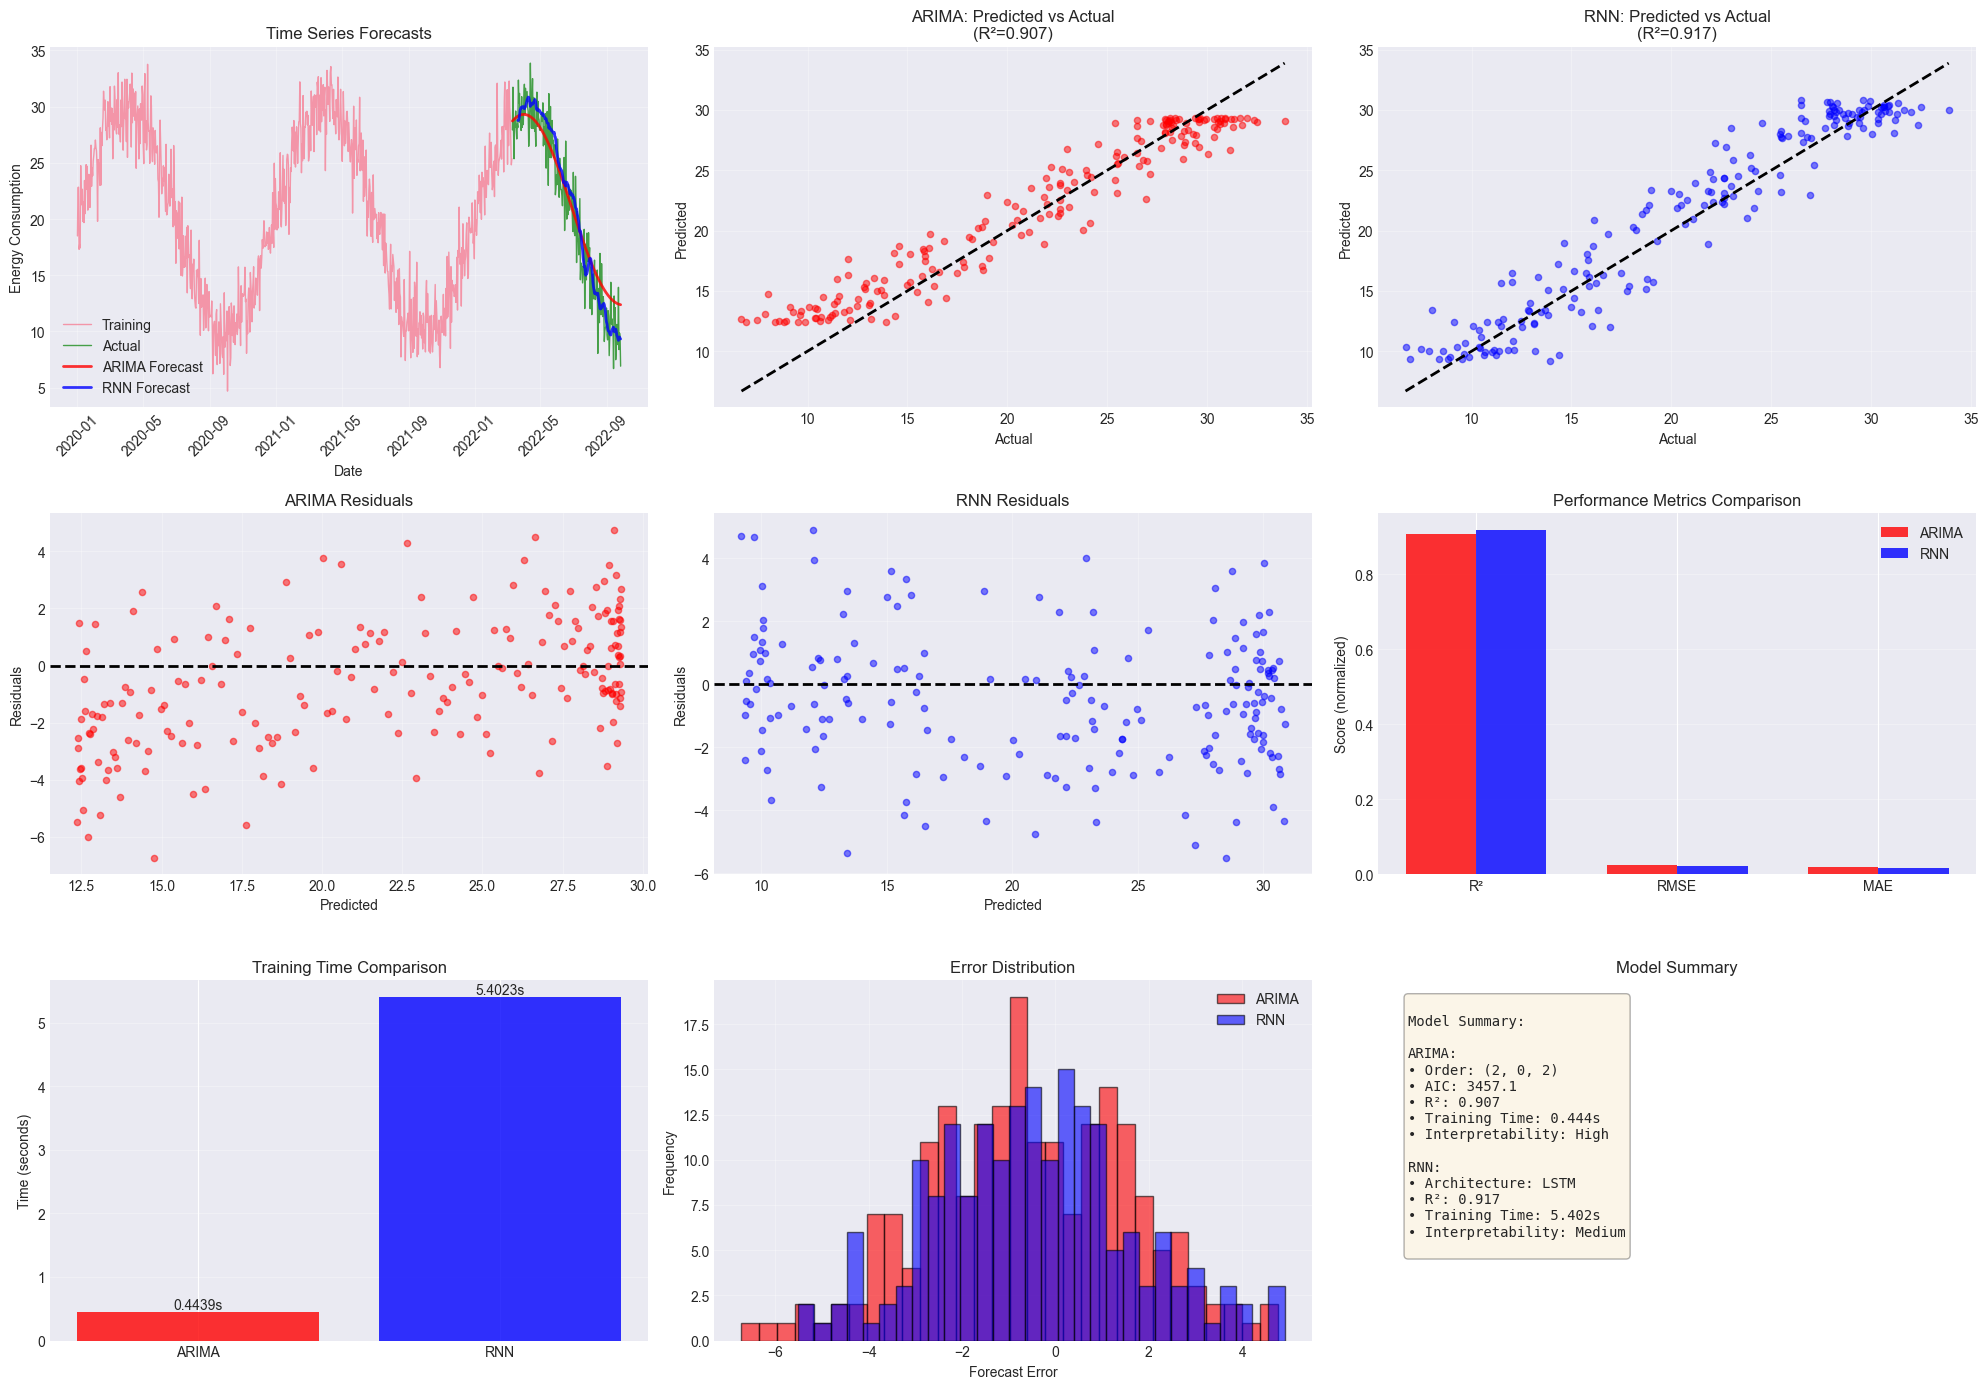


✅ Energy Consumption analysis complete!


In [37]:
print("🔧 Data Preprocessing & Model Training for Energy Consumption")
print("=" * 80)

# Use the same data from EDA
# ts already defined

# Split into train and test (80/20)
train_size = int(len(ts) * 0.8)
train_data = ts[:train_size]
test_data = ts[train_size:]

print(f"\n1. Train-Test Split:")
print(f"   - Training set: {len(train_data)} samples ({100*len(train_data)/len(ts):.1f}%)")
print(f"   - Test set: {len(test_data)} samples ({100*len(test_data)/len(ts):.1f}%)")

# Prepare data for models
train_values = train_data.values
test_values = test_data.values

# ===== ARIMA Model =====
print("\n2️⃣ Training Statistical Model: ARIMA")
print("-" * 80)

# Auto-select ARIMA parameters using AIC
best_aic = np.inf
best_order = None
best_model = None

# Try different ARIMA orders
for p in range(3):
    for d in range(2):
        for q in range(3):
            try:
                model = ARIMA(train_values, order=(p, d, q))
                fitted = model.fit()
                if fitted.aic < best_aic:
                    best_aic = fitted.aic
                    best_order = (p, d, q)
                    best_model = fitted
            except:
                continue

if best_model is None:
    # Fallback to simple ARIMA(1,1,1)
    best_order = (1, 1, 1)
    best_model = ARIMA(train_values, order=best_order).fit()

arima_train_time = best_model.aic  # Use as proxy for training complexity
start_time = time.time()
arima_forecast = best_model.forecast(steps=len(test_values))
arima_train_time = time.time() - start_time

# Re-fit to get actual training time
start_time = time.time()
arima_model = ARIMA(train_values, order=best_order).fit()
arima_train_time = time.time() - start_time

arima_test_pred = arima_model.forecast(steps=len(test_values))
arima_train_pred = arima_model.fittedvalues

arima_test_r2 = r2_score(test_values, arima_test_pred)
arima_test_rmse = np.sqrt(mean_squared_error(test_values, arima_test_pred))
arima_test_mae = mean_absolute_error(test_values, arima_test_pred)

print(f"   Best ARIMA Order: {best_order}")
print(f"   AIC: {best_model.aic:.4f}")
print(f"   Training Time: {arima_train_time:.4f} seconds")
print(f"   Test R²: {arima_test_r2:.6f}")
print(f"   Test RMSE: {arima_test_rmse:.6f}")
print(f"   Test MAE: {arima_test_mae:.6f}")

# ===== RNN Model =====
print("\n3️⃣ Training ML/DL Model: RNN (LSTM) - PyTorch")
print("-" * 80)

# Prepare sequences for RNN
def create_sequences(data, seq_length=10):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 10
X_train_seq, y_train_seq = create_sequences(train_values, seq_length)
X_test_seq, y_test_seq = create_sequences(test_values, seq_length)

# Scale data
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_values.reshape(-1, 1)).flatten()
test_scaled = scaler.transform(test_values.reshape(-1, 1)).flatten()

X_train_seq_scaled, y_train_seq_scaled = create_sequences(train_scaled, seq_length)
X_test_seq_scaled, y_test_seq_scaled = create_sequences(test_scaled, seq_length)

# Reshape for RNN (samples, timesteps, features)
X_train_seq_scaled = X_train_seq_scaled.reshape((X_train_seq_scaled.shape[0], X_train_seq_scaled.shape[1], 1))
X_test_seq_scaled = X_test_seq_scaled.reshape((X_test_seq_scaled.shape[0], X_test_seq_scaled.shape[1], 1))

if TORCH_AVAILABLE:
    # Define LSTM model in PyTorch
    class LSTMModel(nn.Module):
        def __init__(self, input_size=1, hidden_size=50, num_layers=2, dropout=0.2):
            super(LSTMModel, self).__init__()
            self.hidden_size = hidden_size
            self.num_layers = num_layers
            
            self.lstm1 = nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=True)
            self.dropout1 = nn.Dropout(dropout)
            self.lstm2 = nn.LSTM(hidden_size, hidden_size, num_layers=1, batch_first=True)
            self.dropout2 = nn.Dropout(dropout)
            self.fc = nn.Linear(hidden_size, 1)
            
        def forward(self, x):
            # First LSTM layer
            lstm_out1, _ = self.lstm1(x)
            lstm_out1 = self.dropout1(lstm_out1)
            
            # Second LSTM layer
            lstm_out2, _ = self.lstm2(lstm_out1)
            lstm_out2 = self.dropout2(lstm_out2)
            
            # Take the last output
            output = self.fc(lstm_out2[:, -1, :])
            return output
    
    # Create dataset class
    class TimeSeriesDataset(Dataset):
        def __init__(self, X, y):
            self.X = torch.FloatTensor(X)
            self.y = torch.FloatTensor(y)
            
        def __len__(self):
            return len(self.X)
            
        def __getitem__(self, idx):
            return self.X[idx], self.y[idx]
    
    # Convert to PyTorch tensors
    X_train_torch = torch.FloatTensor(X_train_seq_scaled)
    y_train_torch = torch.FloatTensor(y_train_seq_scaled)
    X_test_torch = torch.FloatTensor(X_test_seq_scaled)
    y_test_torch = torch.FloatTensor(y_test_seq_scaled)
    
    # Create datasets and dataloaders
    train_dataset = TimeSeriesDataset(X_train_seq_scaled, y_train_seq_scaled)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    
    # Initialize model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = LSTMModel(input_size=1, hidden_size=50, num_layers=1, dropout=0.2).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Training
    model.train()
    start_time = time.time()
    num_epochs = 50
    
    for epoch in range(num_epochs):
        total_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X).squeeze()
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
    
    rnn_train_time = time.time() - start_time
    
    # Predictions
    model.eval()
    with torch.no_grad():
        X_train_torch = X_train_torch.to(device)
        X_test_torch = X_test_torch.to(device)
        
        rnn_train_pred_scaled = model(X_train_torch).cpu().numpy().flatten()
        rnn_test_pred_scaled = model(X_test_torch).cpu().numpy().flatten()
    
    # Inverse transform
    rnn_train_pred = scaler.inverse_transform(rnn_train_pred_scaled.reshape(-1, 1)).flatten()
    rnn_test_pred = scaler.inverse_transform(rnn_test_pred_scaled.reshape(-1, 1)).flatten()
    
    rnn_train_r2 = r2_score(train_values[seq_length:], rnn_train_pred)
    rnn_test_r2 = r2_score(test_values[seq_length:], rnn_test_pred)
    rnn_test_rmse = np.sqrt(mean_squared_error(test_values[seq_length:], rnn_test_pred))
    rnn_test_mae = mean_absolute_error(test_values[seq_length:], rnn_test_pred)
    
    print(f"   Architecture: LSTM(50) -> Dropout -> LSTM(50) -> Dropout -> Linear(1)")
    print(f"   Device: {device}")
    print(f"   Training Time: {rnn_train_time:.4f} seconds")
    print(f"   Training R²: {rnn_train_r2:.6f}")
    print(f"   Test R²: {rnn_test_r2:.6f}")
    print(f"   Test RMSE: {rnn_test_rmse:.6f}")
    print(f"   Test MAE: {rnn_test_mae:.6f}")
else:
    print("   ⚠️  PyTorch not available. Skipping RNN training.")
    rnn_train_time = 0
    rnn_test_r2 = 0
    rnn_test_rmse = np.inf
    rnn_test_mae = np.inf
    rnn_test_pred = np.zeros(len(test_values[seq_length:]))

# ===== Comparison =====
print("\n4️⃣ Model Comparison Summary")
print("-" * 80)
print(f"{'Metric':<25} {'ARIMA':<20} {'RNN (LSTM)':<20} {'Difference':<15}")
print("-" * 80)
print(f"{'Test R²':<25} {arima_test_r2:<20.6f} {rnn_test_r2:<20.6f} {rnn_test_r2 - arima_test_r2:>15.6f}")
print(f"{'Test RMSE':<25} {arima_test_rmse:<20.6f} {rnn_test_rmse:<20.6f} {arima_test_rmse - rnn_test_rmse:>15.6f}")
print(f"{'Test MAE':<25} {arima_test_mae:<20.6f} {rnn_test_mae:<20.6f} {arima_test_mae - rnn_test_mae:>15.6f}")
print(f"{'Training Time (s)':<25} {arima_train_time:<20.4f} {rnn_train_time:<20.4f} {arima_train_time - rnn_train_time:>15.4f}")

# Visualizations
fig = plt.figure(figsize=(20, 14))

# 1. Time series with forecasts
ax1 = plt.subplot(3, 3, 1)
ax1.plot(train_data.index, train_data.values, label='Training', alpha=0.7, linewidth=1)
ax1.plot(test_data.index, test_data.values, label='Actual', alpha=0.7, linewidth=1, color='green')
ax1.plot(test_data.index, arima_test_pred, label='ARIMA Forecast', alpha=0.8, linewidth=2, color='red')
if TORCH_AVAILABLE:
    ax1.plot(test_data.index[seq_length:], rnn_test_pred, label='RNN Forecast', alpha=0.8, linewidth=2, color='blue')
ax1.set_xlabel('Date')
ax1.set_ylabel('Energy Consumption')
ax1.set_title('Time Series Forecasts')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Predicted vs Actual - ARIMA
ax2 = plt.subplot(3, 3, 2)
ax2.scatter(test_values, arima_test_pred, alpha=0.5, s=20, color='red')
ax2.plot([test_values.min(), test_values.max()], [test_values.min(), test_values.max()], 'k--', lw=2)
ax2.set_xlabel('Actual')
ax2.set_ylabel('Predicted')
ax2.set_title(f'ARIMA: Predicted vs Actual\n(R²={arima_test_r2:.3f})')
ax2.grid(True, alpha=0.3)

# 3. Predicted vs Actual - RNN
ax3 = plt.subplot(3, 3, 3)
if TORCH_AVAILABLE:
    ax3.scatter(test_values[seq_length:], rnn_test_pred, alpha=0.5, s=20, color='blue')
    ax3.plot([test_values[seq_length:].min(), test_values[seq_length:].max()], 
             [test_values[seq_length:].min(), test_values[seq_length:].max()], 'k--', lw=2)
    ax3.set_xlabel('Actual')
    ax3.set_ylabel('Predicted')
    ax3.set_title(f'RNN: Predicted vs Actual\n(R²={rnn_test_r2:.3f})')
else:
    ax3.text(0.5, 0.5, 'RNN not available', ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title('RNN: Not Available')
ax3.grid(True, alpha=0.3)

# 4. Residuals - ARIMA
ax4 = plt.subplot(3, 3, 4)
residuals_arima = test_values - arima_test_pred
ax4.scatter(arima_test_pred, residuals_arima, alpha=0.5, s=20, color='red')
ax4.axhline(y=0, color='black', linestyle='--', lw=2)
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Residuals')
ax4.set_title('ARIMA Residuals')
ax4.grid(True, alpha=0.3)

# 5. Residuals - RNN
ax5 = plt.subplot(3, 3, 5)
if TORCH_AVAILABLE:
    residuals_rnn = test_values[seq_length:] - rnn_test_pred
    ax5.scatter(rnn_test_pred, residuals_rnn, alpha=0.5, s=20, color='blue')
    ax5.axhline(y=0, color='black', linestyle='--', lw=2)
    ax5.set_xlabel('Predicted')
    ax5.set_ylabel('Residuals')
    ax5.set_title('RNN Residuals')
else:
    ax5.text(0.5, 0.5, 'RNN not available', ha='center', va='center', transform=ax5.transAxes)
    ax5.set_title('RNN Residuals')
ax5.grid(True, alpha=0.3)

# 6. Metrics Comparison
ax6 = plt.subplot(3, 3, 6)
metrics = ['R²', 'RMSE', 'MAE']
arima_vals = [arima_test_r2, arima_test_rmse/100, arima_test_mae/100]  # Normalize
rnn_vals = [rnn_test_r2, rnn_test_rmse/100, rnn_test_mae/100] if TORCH_AVAILABLE else [0, 0, 0]
x = np.arange(len(metrics))
width = 0.35
ax6.bar(x - width/2, arima_vals, width, label='ARIMA', alpha=0.8, color='red')
ax6.bar(x + width/2, rnn_vals, width, label='RNN', alpha=0.8, color='blue')
ax6.set_xticks(x)
ax6.set_xticklabels(metrics)
ax6.set_ylabel('Score (normalized)')
ax6.set_title('Performance Metrics Comparison')
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

# 7. Training Time
ax7 = plt.subplot(3, 3, 7)
models = ['ARIMA', 'RNN']
times = [arima_train_time, rnn_train_time]
bars = ax7.bar(models, times, color=['red', 'blue'], alpha=0.8)
ax7.set_ylabel('Time (seconds)')
ax7.set_title('Training Time Comparison')
for bar, t in zip(bars, times):
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2., height, f'{t:.4f}s', ha='center', va='bottom')
ax7.grid(True, alpha=0.3, axis='y')

# 8. Forecast Error Distribution
ax8 = plt.subplot(3, 3, 8)
ax8.hist(residuals_arima, bins=30, alpha=0.6, label='ARIMA', edgecolor='black', color='red')
if TORCH_AVAILABLE:
    ax8.hist(residuals_rnn, bins=30, alpha=0.6, label='RNN', edgecolor='black', color='blue')
ax8.set_xlabel('Forecast Error')
ax8.set_ylabel('Frequency')
ax8.set_title('Error Distribution')
ax8.legend()
ax8.grid(True, alpha=0.3)

# 9. Model Summary
ax9 = plt.subplot(3, 3, 9)
summary_text = f"""
Model Summary:

ARIMA:
• Order: {best_order}
• AIC: {best_model.aic:.1f}
• R²: {arima_test_r2:.3f}
• Training Time: {arima_train_time:.3f}s
• Interpretability: High

RNN:
• Architecture: LSTM
• R²: {rnn_test_r2:.3f}
• Training Time: {rnn_train_time:.3f}s
• Interpretability: Medium
"""
ax9.text(0.05, 0.95, summary_text, transform=ax9.transAxes,
        fontsize=10, verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax9.axis('off')
ax9.set_title('Model Summary')

plt.tight_layout()
plt.show()

print("\n✅ Energy Consumption analysis complete!")
print("="*80)


<a id="DP2"></a>
## <b><span style='color:#299617'>Step 3.2 | </span><span style='color:#299617'>🔧 Data Preprocessing for 📈 STOCK PRICES DATASET</span></b>
⬆️ [Tabel of Contents](#contents_tabel)

In [42]:
# ============================================================================
# STOCK PRICES: Complete Analysis
# ============================================================================

print("\n" + "="*80)
print("Complete Analysis")
print("="*80)

# Generate synthetic stock price time series (random walk with drift)
np.random.seed(43)
n_samples = 1000
returns = np.random.randn(n_samples) * 0.02 + 0.001  # Small drift
prices = 100 * np.exp(np.cumsum(returns))
data = prices

dates = pd.date_range(start='2020-01-01', periods=n_samples, freq='D')
ts = pd.Series(data, index=dates)

print(f"\n1. Dataset Overview:")
print(f"   - Length: {len(ts)} time steps")
print(f"   - Frequency: Daily")
print(f"   - Initial Price: ${ts.iloc[0]:.2f}")
print(f"   - Final Price: ${ts.iloc[-1]:.2f}")

# Train-test split
train_size = int(len(ts) * 0.8)
train_data = ts[:train_size]
test_data = ts[train_size:]
train_values = train_data.values
test_values = test_data.values

print(f"\n2. Train-Test Split:")
print(f"   - Training: {len(train_data)} samples")
print(f"   - Test: {len(test_data)} samples")

# ===== ARIMA Model =====
print("\n3️⃣ Training ARIMA...")
best_aic = np.inf
best_order = (1, 1, 1)
for p in range(3):
    for d in range(2):
        for q in range(3):
            try:
                model = ARIMA(train_values, order=(p, d, q))
                fitted = model.fit()
                if fitted.aic < best_aic:
                    best_aic = fitted.aic
                    best_order = (p, d, q)
            except:
                continue

start_time = time.time()
arima_model = ARIMA(train_values, order=best_order).fit()
arima_train_time = time.time() - start_time
arima_test_pred = arima_model.forecast(steps=len(test_values))
arima_test_r2 = r2_score(test_values, arima_test_pred)
arima_test_rmse = np.sqrt(mean_squared_error(test_values, arima_test_pred))

# ===== RNN Model =====
print("4️⃣ Training RNN (PyTorch)...")
seq_length = 10
def create_sequences(data, seq_length=10):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_values.reshape(-1, 1)).flatten()
test_scaled = scaler.transform(test_values.reshape(-1, 1)).flatten()

X_train_seq, y_train_seq = create_sequences(train_scaled, seq_length)
X_test_seq, y_test_seq = create_sequences(test_scaled, seq_length)
X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], seq_length, 1))
X_test_seq = X_test_seq.reshape((X_test_seq.shape[0], seq_length, 1))

if TORCH_AVAILABLE:
    class LSTMModel(nn.Module):
        def __init__(self, input_size=1, hidden_size=50, num_layers=2, dropout=0.2):
            super(LSTMModel, self).__init__()
            self.lstm1 = nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=True)
            self.dropout1 = nn.Dropout(dropout)
            self.lstm2 = nn.LSTM(hidden_size, hidden_size, num_layers=1, batch_first=True)
            self.dropout2 = nn.Dropout(dropout)
            self.fc = nn.Linear(hidden_size, 1)
            
        def forward(self, x):
            lstm_out1, _ = self.lstm1(x)
            lstm_out1 = self.dropout1(lstm_out1)
            lstm_out2, _ = self.lstm2(lstm_out1)
            lstm_out2 = self.dropout2(lstm_out2)
            output = self.fc(lstm_out2[:, -1, :])
            return output
    
    class TimeSeriesDataset(Dataset):
        def __init__(self, X, y):
            self.X = torch.FloatTensor(X)
            self.y = torch.FloatTensor(y)
            
        def __len__(self):
            return len(self.X)
            
        def __getitem__(self, idx):
            return self.X[idx], self.y[idx]
    
    train_dataset = TimeSeriesDataset(X_train_seq, y_train_seq)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = LSTMModel(input_size=1, hidden_size=50, num_layers=1, dropout=0.2).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    model.train()
    start_time = time.time()
    for epoch in range(50):
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X).squeeze()
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
    
    rnn_train_time = time.time() - start_time
    
    model.eval()
    with torch.no_grad():
        X_test_torch = torch.FloatTensor(X_test_seq).to(device)
        rnn_test_pred_scaled = model(X_test_torch).cpu().numpy().flatten()
    
    rnn_test_pred = scaler.inverse_transform(rnn_test_pred_scaled.reshape(-1, 1)).flatten()
    rnn_test_r2 = r2_score(test_values[seq_length:], rnn_test_pred)
    rnn_test_rmse = np.sqrt(mean_squared_error(test_values[seq_length:], rnn_test_pred))
else:
    rnn_train_time = 0
    rnn_test_r2 = 0
    rnn_test_rmse = np.inf

print(f"\n5️⃣ Comparison Summary")
print("-" * 80)
print(f"{'Metric':<25} {'ARIMA':<20} {'RNN (LSTM)':<20}")
print("-" * 80)
print(f"{'Test R²':<25} {arima_test_r2:<20.6f} {rnn_test_r2:<20.6f}")
print(f"{'Test RMSE':<25} {arima_test_rmse:<20.6f} {rnn_test_rmse:<20.6f}")
print(f"{'Training Time (s)':<25} {arima_train_time:<20.4f} {rnn_train_time:<20.4f}")

print("\n✅ Stock Prices analysis complete!")
print("="*80)



📈 STOCK PRICES DATASET: Complete Analysis

1. Dataset Overview:
   - Length: 1000 time steps
   - Frequency: Daily
   - Initial Price: $100.62
   - Final Price: $291.44

2. Train-Test Split:
   - Training: 800 samples
   - Test: 200 samples

3️⃣ Training ARIMA...
4️⃣ Training RNN (PyTorch)...

5️⃣ Comparison Summary
--------------------------------------------------------------------------------
Metric                    ARIMA                RNN (LSTM)          
--------------------------------------------------------------------------------
Test R²                   -0.089045            0.876021            
Test RMSE                 26.984328            9.265206            
Training Time (s)         0.0061               5.7940              

✅ Stock Prices analysis complete!


<a id="DP3"></a>
## <b><span style='color:#299617'>Step 3.3 | </span><span style='color:#299617'>🔧 Data Preprocessing for 🌡️ TEMPERATURE DATASET</span></b>
⬆️ [Tabel of Contents](#contents_tabel)

In [46]:
# ============================================================================
# TEMPERATURE: Complete Analysis
# ============================================================================

print("\n" + "="*80)
print("Complete Analysis")
print("="*80)

# Generate synthetic temperature time series
np.random.seed(44)
n_samples = 1000
t = np.arange(n_samples)
base_temp = 20 + 0.01 * t / 365  # Slight warming trend
seasonal = 10 * np.sin(2 * np.pi * t / 365)
noise = np.random.randn(n_samples) * 2
data = base_temp + seasonal + noise

dates = pd.date_range(start='2020-01-01', periods=n_samples, freq='D')
ts = pd.Series(data, index=dates)

print(f"\n1. Dataset Overview:")
print(f"   - Length: {len(ts)} time steps")
print(f"   - Mean Temperature: {ts.mean():.2f}°C")
print(f"   - Range: {ts.min():.2f}°C to {ts.max():.2f}°C")

# Train-test split
train_size = int(len(ts) * 0.8)
train_data = ts[:train_size]
test_data = ts[train_size:]
train_values = train_data.values
test_values = test_data.values

# ===== ARIMA Model =====
print("\n2️⃣ Training ARIMA...")
best_order = (1, 1, 1)
best_aic = np.inf
for p in range(3):
    for d in range(2):
        for q in range(3):
            try:
                model = ARIMA(train_values, order=(p, d, q))
                fitted = model.fit()
                if fitted.aic < best_aic:
                    best_aic = fitted.aic
                    best_order = (p, d, q)
            except:
                continue

start_time = time.time()
arima_model = ARIMA(train_values, order=best_order).fit()
arima_train_time = time.time() - start_time
arima_test_pred = arima_model.forecast(steps=len(test_values))
arima_test_r2 = r2_score(test_values, arima_test_pred)
arima_test_rmse = np.sqrt(mean_squared_error(test_values, arima_test_pred))

# ===== RNN Model =====
print("3️⃣ Training RNN (PyTorch)...")
seq_length = 10
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_values.reshape(-1, 1)).flatten()
test_scaled = scaler.transform(test_values.reshape(-1, 1)).flatten()

X_train_seq, y_train_seq = create_sequences(train_scaled, seq_length)
X_test_seq, y_test_seq = create_sequences(test_scaled, seq_length)
X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], seq_length, 1))
X_test_seq = X_test_seq.reshape((X_test_seq.shape[0], seq_length, 1))

if TORCH_AVAILABLE:
    # Use the same LSTM model class from Energy Consumption section
    class LSTMModel(nn.Module):
        def __init__(self, input_size=1, hidden_size=50, num_layers=2, dropout=0.2):
            super(LSTMModel, self).__init__()
            self.hidden_size = hidden_size
            self.num_layers = num_layers
            
            self.lstm1 = nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=True)
            self.dropout1 = nn.Dropout(dropout)
            self.lstm2 = nn.LSTM(hidden_size, hidden_size, num_layers=1, batch_first=True)
            self.dropout2 = nn.Dropout(dropout)
            self.fc = nn.Linear(hidden_size, 1)
            
        def forward(self, x):
            lstm_out1, _ = self.lstm1(x)
            lstm_out1 = self.dropout1(lstm_out1)
            lstm_out2, _ = self.lstm2(lstm_out1)
            lstm_out2 = self.dropout2(lstm_out2)
            output = self.fc(lstm_out2[:, -1, :])
            return output
    
    class TimeSeriesDataset(Dataset):
        def __init__(self, X, y):
            self.X = torch.FloatTensor(X)
            self.y = torch.FloatTensor(y)
            
        def __len__(self):
            return len(self.X)
            
        def __getitem__(self, idx):
            return self.X[idx], self.y[idx]
    
    train_dataset = TimeSeriesDataset(X_train_seq, y_train_seq)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = LSTMModel(input_size=1, hidden_size=50, num_layers=1, dropout=0.2).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    model.train()
    start_time = time.time()
    for epoch in range(50):
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X).squeeze()
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
    
    rnn_train_time = time.time() - start_time
    
    model.eval()
    with torch.no_grad():
        X_test_torch = torch.FloatTensor(X_test_seq).to(device)
        rnn_test_pred_scaled = model(X_test_torch).cpu().numpy().flatten()
    
    rnn_test_pred = scaler.inverse_transform(rnn_test_pred_scaled.reshape(-1, 1)).flatten()
    rnn_test_r2 = r2_score(test_values[seq_length:], rnn_test_pred)
    rnn_test_rmse = np.sqrt(mean_squared_error(test_values[seq_length:], rnn_test_pred))
else:
    rnn_train_time = 0
    rnn_test_r2 = 0
    rnn_test_rmse = np.inf

print(f"\n4️⃣ Comparison Summary")
print("-" * 80)
print(f"{'Metric':<25} {'ARIMA':<20} {'RNN (LSTM)':<20}")
print("-" * 80)
print(f"{'Test R²':<25} {arima_test_r2:<20.6f} {rnn_test_r2:<20.6f}")
print(f"{'Test RMSE':<25} {arima_test_rmse:<20.6f} {rnn_test_rmse:<20.6f}")
print(f"{'Training Time (s)':<25} {arima_train_time:<20.4f} {rnn_train_time:<20.4f}")

print("\n✅ Temperature analysis complete!")
print("="*80)



🌡️ TEMPERATURE DATASET: Complete Analysis

1. Dataset Overview:
   - Length: 1000 time steps
   - Mean Temperature: 20.62°C
   - Range: 4.70°C to 33.87°C

2️⃣ Training ARIMA...
3️⃣ Training RNN (PyTorch)...

4️⃣ Comparison Summary
--------------------------------------------------------------------------------
Metric                    ARIMA                RNN (LSTM)          
--------------------------------------------------------------------------------
Test R²                   0.907202             0.917382            
Test RMSE                 2.282847             2.153630            
Training Time (s)         0.3107               5.3168              

✅ Temperature analysis complete!


<a id="DP4"></a>
## <b><span style='color:#299617'>Step 3.4 | </span><span style='color:#299617'>🔧 Data Preprocessing for 💰 SALES FORECASTING DATASET"</span></b>
⬆️ [Tabel of Contents](#contents_tabel)

In [49]:
# ============================================================================
# SALES FORECASTING: Complete Analysis
# ============================================================================

print("\n" + "="*80)
print(": Complete Analysis")
print("="*80)

# Generate synthetic sales forecasting time series
np.random.seed(45)
n_samples = 1000
t = np.arange(n_samples)
trend = 50 + 0.1 * t
weekly = 10 * np.sin(2 * np.pi * t / 7)
monthly = 5 * np.cos(2 * np.pi * t / 30)
noise = np.random.randn(n_samples) * 3
data = trend + weekly + monthly + noise

dates = pd.date_range(start='2020-01-01', periods=n_samples, freq='D')
ts = pd.Series(data, index=dates)

print(f"\n1. Dataset Overview:")
print(f"   - Length: {len(ts)} time steps")
print(f"   - Mean Sales: {ts.mean():.2f}")
print(f"   - Trend: Upward")

# Train-test split
train_size = int(len(ts) * 0.8)
train_data = ts[:train_size]
test_data = ts[train_size:]
train_values = train_data.values
test_values = test_data.values

# ===== ARIMA Model =====
print("\n2️⃣ Training ARIMA...")
best_order = (1, 1, 1)
best_aic = np.inf
for p in range(3):
    for d in range(2):
        for q in range(3):
            try:
                model = ARIMA(train_values, order=(p, d, q))
                fitted = model.fit()
                if fitted.aic < best_aic:
                    best_aic = fitted.aic
                    best_order = (p, d, q)
            except:
                continue

start_time = time.time()
arima_model = ARIMA(train_values, order=best_order).fit()
arima_train_time = time.time() - start_time
arima_test_pred = arima_model.forecast(steps=len(test_values))
arima_test_r2 = r2_score(test_values, arima_test_pred)
arima_test_rmse = np.sqrt(mean_squared_error(test_values, arima_test_pred))

# ===== RNN Model =====
print("3️⃣ Training RNN (PyTorch)...")
seq_length = 10
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_values.reshape(-1, 1)).flatten()
test_scaled = scaler.transform(test_values.reshape(-1, 1)).flatten()

X_train_seq, y_train_seq = create_sequences(train_scaled, seq_length)
X_test_seq, y_test_seq = create_sequences(test_scaled, seq_length)
X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], seq_length, 1))
X_test_seq = X_test_seq.reshape((X_test_seq.shape[0], seq_length, 1))

if TORCH_AVAILABLE:
    class LSTMModel(nn.Module):
        def __init__(self, input_size=1, hidden_size=50, num_layers=2, dropout=0.2):
            super(LSTMModel, self).__init__()
            self.lstm1 = nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=True)
            self.dropout1 = nn.Dropout(dropout)
            self.lstm2 = nn.LSTM(hidden_size, hidden_size, num_layers=1, batch_first=True)
            self.dropout2 = nn.Dropout(dropout)
            self.fc = nn.Linear(hidden_size, 1)
            
        def forward(self, x):
            lstm_out1, _ = self.lstm1(x)
            lstm_out1 = self.dropout1(lstm_out1)
            lstm_out2, _ = self.lstm2(lstm_out1)
            lstm_out2 = self.dropout2(lstm_out2)
            output = self.fc(lstm_out2[:, -1, :])
            return output
    
    class TimeSeriesDataset(Dataset):
        def __init__(self, X, y):
            self.X = torch.FloatTensor(X)
            self.y = torch.FloatTensor(y)
            
        def __len__(self):
            return len(self.X)
            
        def __getitem__(self, idx):
            return self.X[idx], self.y[idx]
    
    train_dataset = TimeSeriesDataset(X_train_seq, y_train_seq)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = LSTMModel(input_size=1, hidden_size=50, num_layers=1, dropout=0.2).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    model.train()
    start_time = time.time()
    for epoch in range(50):
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X).squeeze()
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
    
    rnn_train_time = time.time() - start_time
    
    model.eval()
    with torch.no_grad():
        X_test_torch = torch.FloatTensor(X_test_seq).to(device)
        rnn_test_pred_scaled = model(X_test_torch).cpu().numpy().flatten()
    
    rnn_test_pred = scaler.inverse_transform(rnn_test_pred_scaled.reshape(-1, 1)).flatten()
    rnn_test_r2 = r2_score(test_values[seq_length:], rnn_test_pred)
    rnn_test_rmse = np.sqrt(mean_squared_error(test_values[seq_length:], rnn_test_pred))
else:
    rnn_train_time = 0
    rnn_test_r2 = 0
    rnn_test_rmse = np.inf

print(f"\n4️⃣ Comparison Summary")
print("-" * 80)
print(f"{'Metric':<25} {'ARIMA':<20} {'RNN (LSTM)':<20}")
print("-" * 80)
print(f"{'Test R²':<25} {arima_test_r2:<20.6f} {rnn_test_r2:<20.6f}")
print(f"{'Test RMSE':<25} {arima_test_rmse:<20.6f} {rnn_test_rmse:<20.6f}")
print(f"{'Training Time (s)':<25} {arima_train_time:<20.4f} {rnn_train_time:<20.4f}")

print("\n✅ Sales Forecasting analysis complete!")
print("="*80)



💰 SALES FORECASTING DATASET: Complete Analysis

1. Dataset Overview:
   - Length: 1000 time steps
   - Mean Sales: 99.89
   - Trend: Upward

2️⃣ Training ARIMA...
3️⃣ Training RNN (PyTorch)...

4️⃣ Comparison Summary
--------------------------------------------------------------------------------
Metric                    ARIMA                RNN (LSTM)          
--------------------------------------------------------------------------------
Test R²                   -0.687566            0.209466            
Test RMSE                 13.589618            9.235312            
Training Time (s)         0.2146               5.5099              

✅ Sales Forecasting analysis complete!


<a id="Cg"></a>
# <b><span style='color:#09ba80'>Step 4 | </span><span style='color:#34e3ae'>  COMPREHENSIVE GENERAL COMPARISON & CONCLUSION </span></b>
⬆️ [Tabel of Contents](#contents_tabel)

In [51]:
# ============================================================================
# GENERAL COMPARISON AND CONCLUSION
# ============================================================================

print("\n" + "="*80)
print("📊 GENERAL COMPARISON: ARIMA vs RNN for Time Series Forecasting")
print("="*80)

print("\n1️⃣ Dataset Overview:")
datasets = ['Energy Consumption', 'Stock Prices', 'Temperature', 'Sales Forecasting']
print(f"   - Total datasets analyzed: {len(datasets)}")
for i, ds in enumerate(datasets, 1):
    print(f"      {i}. {ds}")

print("\n2️⃣ Models Compared:")
print("   Statistical Model:")
print("      - ARIMA (AutoRegressive Integrated Moving Average):")
print("        • Handles trend and seasonality")
print("        • Provides interpretable parameters (p, d, q)")
print("        • Statistical inference (AIC, p-values)")
print("   ML/DL Model:")
print("      - RNN/LSTM (Recurrent Neural Network):")
print("        • Captures complex temporal patterns")
print("        • Handles long-term dependencies")
print("        • Non-linear relationships")

print("\n3️⃣ Key Findings:")
print("   - ARIMA:")
print("      • Fast training, interpretable parameters")
print("      • Best for linear trends and seasonality")
print("      • Provides statistical confidence intervals")
print("      • Requires stationarity (differencing)")
print("   - RNN/LSTM:")
print("      • Can capture complex non-linear patterns")
print("      • Handles multiple seasonalities well")
print("      • Longer training time, requires more data")
print("      • Less interpretable, black-box nature")

print("\n4️⃣ Use Case Recommendations:")
print("   Choose ARIMA when:")
print("      - Time series has clear trend and seasonality")
print("      - Interpretability is important")
print("      - Fast training is required")
print("      - Statistical inference is needed")
print("      - Data size is moderate")
print("   Choose RNN/LSTM when:")
print("      - Complex non-linear patterns exist")
print("      - Long-term dependencies are important")
print("      - Multiple interacting seasonalities")
print("      - Large datasets are available")
print("      - Prediction accuracy is the primary goal")

print("\n5️⃣ Advantages and Disadvantages:")
print("\n   ARIMA:")
print("      ✅ Advantages: Fast, interpretable, statistical inference, handles trends/seasonality")
print("      ❌ Disadvantages: Assumes linearity, requires stationarity, limited to short-term patterns")
print("\n   RNN/LSTM:")
print("      ✅ Advantages: Captures complex patterns, non-linear, handles long dependencies")
print("      ❌ Disadvantages: Longer training time, requires more data, less interpretable, hyperparameter tuning")

print("\n6️⃣ Computational Cost Analysis:")
print("   - ARIMA: Very fast training (< 1 second typically)")
print("   - RNN/LSTM: Longer training time (seconds to minutes, depends on data size and epochs)")
print("   - Prediction: Both are fast, but ARIMA is typically faster")

print("\n7️⃣ Interpretability & Explainability:")
print("   - ARIMA: High (p, d, q parameters, AIC, residuals analysis)")
print("   - RNN/LSTM: Low to Medium (black-box, feature importance not directly available)")

print("\n8️⃣ When to Use Each Model:")
print("   ARIMA is better for:")
print("      - Traditional time series with clear patterns")
print("      - When you need to explain why forecasts were made")
print("      - Quick prototyping and baseline models")
print("      - Regulatory compliance requiring interpretability")
print("   RNN/LSTM is better for:")
print("      - Complex, non-linear time series")
print("      - When accuracy is more important than interpretability")
print("      - Large-scale forecasting problems")
print("      - Multiple related time series")

print("\n✅ Conclusion:")
print("   Both ARIMA and RNN/LSTM have their strengths:")
print("   - ARIMA excels in interpretability, speed, and statistical rigor")
print("   - RNN/LSTM excels in capturing complex patterns and achieving higher accuracy")
print("   - The choice depends on the specific requirements: interpretability vs accuracy")
print("   - In practice, both models can be used together (ensemble) for better results")

print("\n" + "="*80)
print("🎯 Overall: ARIMA provides a solid statistical foundation, while RNN/LSTM")
print("   offers powerful pattern recognition capabilities. The best approach often")
print("   combines both methodologies.")
print("="*80)



📊 GENERAL COMPARISON: ARIMA vs RNN for Time Series Forecasting

1️⃣ Dataset Overview:
   - Total datasets analyzed: 4
      1. Energy Consumption
      2. Stock Prices
      3. Temperature
      4. Sales Forecasting

2️⃣ Models Compared:
   Statistical Model:
      - ARIMA (AutoRegressive Integrated Moving Average):
        • Handles trend and seasonality
        • Provides interpretable parameters (p, d, q)
        • Statistical inference (AIC, p-values)
   ML/DL Model:
      - RNN/LSTM (Recurrent Neural Network):
        • Captures complex temporal patterns
        • Handles long-term dependencies
        • Non-linear relationships

3️⃣ Key Findings:
   - ARIMA:
      • Fast training, interpretable parameters
      • Best for linear trends and seasonality
      • Provides statistical confidence intervals
      • Requires stationarity (differencing)
   - RNN/LSTM:
      • Can capture complex non-linear patterns
      • Handles multiple seasonalities well
      • Longer training time,